# Customer Churn Prediction — From Data to Model

This notebook walks through the full ML pipeline:
1. Load the Kaggle e-commerce churn dataset
2. Exploratory Data Analysis
3. Preprocessing (imputation, encoding, scaling)
4. Train & tune three models: Random Forest, MLP, SVM
5. Model comparison (ROC curves, metrics, confusion matrices)
6. Select & save the best model for deployment

## 1. Setup & Data Loading

In [1]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, accuracy_score, f1_score, fbeta_score,
    precision_score, recall_score, make_scorer,
)
import joblib

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

f2_scorer = make_scorer(fbeta_score, beta=2)

In [2]:
df = pd.read_csv("../datasets/data_ecommerce_customer_churn.csv")
print(f"Rows: {len(df):,}")
print(f"Columns: {list(df.columns)}")
df.head()

Rows: 3,941
Columns: ['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'DaySinceLastOrder', 'CashbackAmount', 'Churn']


,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0


In [3]:
print("Data types:")
print(df.dtypes)
print(f"\nNull counts:")
print(df.isnull().sum())
print(f"\nBasic stats:")
df.describe()

Data types:
Tenure                      float64
WarehouseToHome             float64
NumberOfDeviceRegistered      int64
PreferedOrderCat             object
SatisfactionScore             int64
MaritalStatus                object
NumberOfAddress               int64
Complain                      int64
DaySinceLastOrder           float64
CashbackAmount              float64
Churn                         int64
dtype: object

Null counts:
Tenure                      194
WarehouseToHome             169
NumberOfDeviceRegistered      0
PreferedOrderCat              0
SatisfactionScore             0
MaritalStatus                 0
NumberOfAddress               0
Complain                      0
DaySinceLastOrder           213
CashbackAmount                0
Churn                         0
dtype: int64

Basic stats:


,Tenure,WarehouseToHome,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
count,3747.000000,3772.000000,3941.000000,3941.000000,3941.000000,3941.000000,3728.000000,3941.000000,3941.000000
mean,10.081398,15.650583,3.679269,3.088302,4.237757,0.282416,4.531652,176.707419,0.171023
std,8.498864,8.452301,1.013938,1.381832,2.626699,0.450232,3.667648,48.791784,0.376576
min,0.000000,5.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,9.000000,3.000000,2.000000,2.000000,0.000000,2.000000,145.700000,0.000000
50%,9.000000,14.000000,4.000000,3.000000,3.000000,0.000000,3.000000,163.340000,0.000000
75%,16.000000,21.000000,4.000000,4.000000,6.000000,1.000000,7.000000,195.250000,0.000000
max,61.000000,127.000000,6.000000,5.000000,22.000000,1.000000,46.000000,324.990000,1.000000


## 2. Exploratory Data Analysis

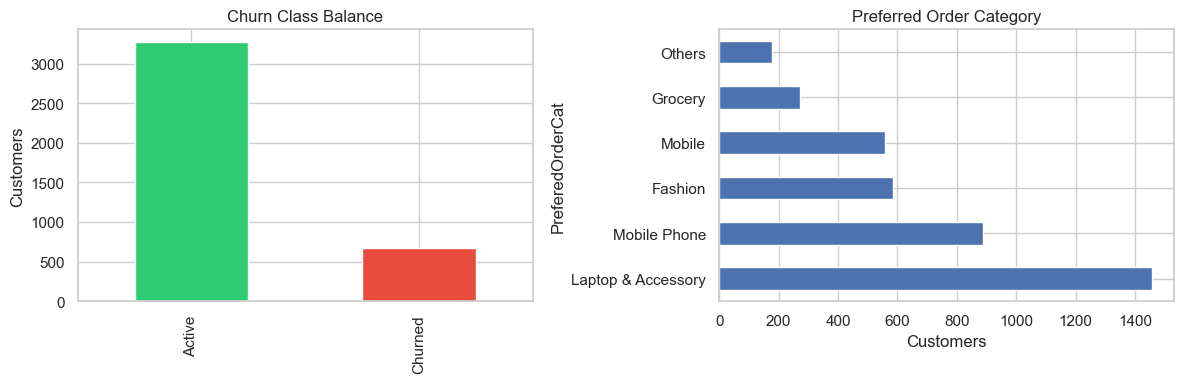

Churn rate: 17.1%


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

churn_counts = df["Churn"].value_counts()
churn_counts.index = ["Active", "Churned"]
churn_counts.plot(kind="bar", ax=axes[0], color=["#2ecc71", "#e74c3c"])
axes[0].set_title("Churn Class Balance")
axes[0].set_ylabel("Customers")

df["PreferedOrderCat"].value_counts().plot(kind="barh", ax=axes[1])
axes[1].set_title("Preferred Order Category")
axes[1].set_xlabel("Customers")

plt.tight_layout()
plt.show()
print(f"Churn rate: {df['Churn'].mean():.1%}")

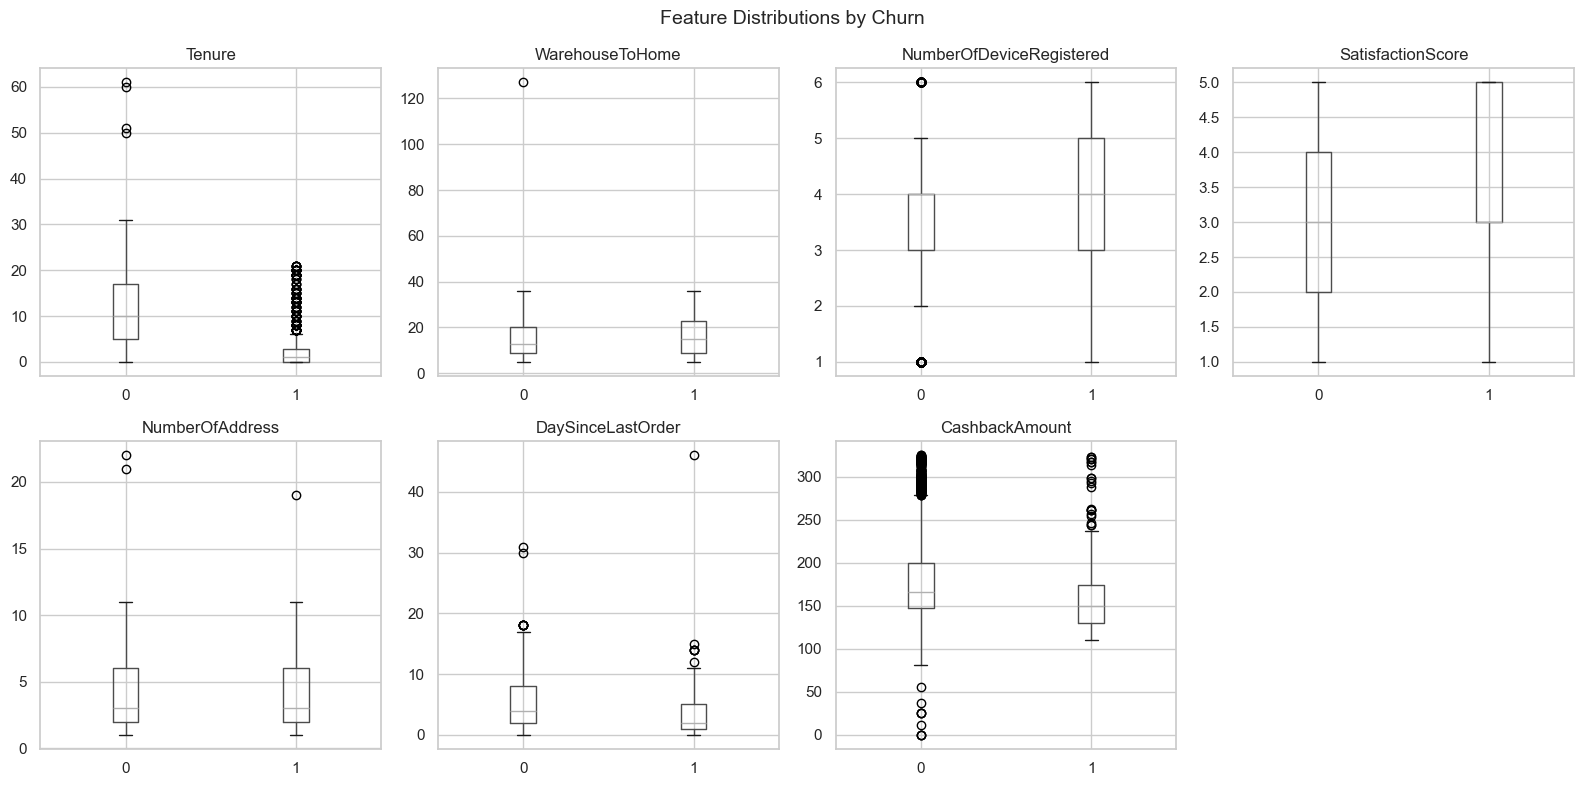

In [5]:
numeric_cols = ["Tenure", "WarehouseToHome", "NumberOfDeviceRegistered",
                "SatisfactionScore", "NumberOfAddress", "DaySinceLastOrder", "CashbackAmount"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, col in enumerate(numeric_cols):
    ax = axes[i // 4, i % 4]
    df.boxplot(column=col, by="Churn", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")

axes[1, 3].axis("off")
plt.suptitle("Feature Distributions by Churn", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Preprocessing

- Impute nulls (Tenure, WarehouseToHome, DaySinceLastOrder) with median
- One-hot encode categoricals (PreferedOrderCat, MaritalStatus)

In [6]:
impute_medians = {}
for col in ["Tenure", "WarehouseToHome", "DaySinceLastOrder"]:
    median_val = df[col].median()
    impute_medians[col] = median_val
    df[col] = df[col].fillna(median_val).astype(int)

print("Imputation medians:", impute_medians)
print("Remaining nulls:", df.isnull().sum().sum())

Imputation medians: {'Tenure': 9.0, 'WarehouseToHome': 14.0, 'DaySinceLastOrder': 3.0}
Remaining nulls: 0


In [7]:
target = "Churn"

feature_df = df.drop(columns=[target])
feature_df = pd.get_dummies(feature_df, columns=["PreferedOrderCat", "MaritalStatus"], drop_first=True)

X = feature_df
y = df[target]

print(f"Feature matrix shape: {X.shape}")
print(f"Feature columns: {list(X.columns)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set: {len(X_train):,} customers")
print(f"Test set:     {len(X_test):,} customers")

Feature matrix shape: (3941, 15)
Feature columns: ['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'DaySinceLastOrder', 'CashbackAmount', 'PreferedOrderCat_Grocery', 'PreferedOrderCat_Laptop & Accessory', 'PreferedOrderCat_Mobile', 'PreferedOrderCat_Mobile Phone', 'PreferedOrderCat_Others', 'MaritalStatus_Married', 'MaritalStatus_Single']

Training set: 3,152 customers
Test set:     789 customers


## 3b. Feature Scaling

MLP and SVM are sensitive to feature magnitudes. We fit a StandardScaler on the training set and transform both sets. Random Forest does not need scaling.

In [8]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index,
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index,
)
print(f"Scaler fitted on {X_train_scaled.shape[0]} training samples")
print(f"Sample scaled means (should be ~0):\n{X_train_scaled.mean().round(4).head()}")

Scaler fitted on 3152 training samples
Sample scaled means (should be ~0):
Tenure                      0.0
WarehouseToHome             0.0
NumberOfDeviceRegistered    0.0
SatisfactionScore           0.0
NumberOfAddress            -0.0
dtype: float64


## 4a. Random Forest — Hyperparameter Tuning

We search over key RandomForest hyperparameters using 5-fold cross-validation, scoring on F2 (recall-weighted) since missing a churner is more costly than a false alarm.

In [9]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring=f2_scorer,
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_train, y_train)

print(f"\nBest F2 score (CV): {grid_search.best_score_:.4f}")
print(f"Best params: {grid_search.best_params_}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best F2 score (CV): 0.7192
Best params: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [10]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print(f"Test accuracy: {(y_pred == y_test).mean():.4f}\n")
print(classification_report(y_test, y_pred, target_names=["Active", "Churned"]))

Test accuracy: 0.9354

              precision    recall  f1-score   support

      Active       0.94      0.98      0.96       654
     Churned       0.90      0.70      0.79       135

    accuracy                           0.94       789
   macro avg       0.92      0.84      0.88       789
weighted avg       0.93      0.94      0.93       789



In [11]:
results = {}

y_pred_rf = best_model.predict(X_test)
y_proba_rf = best_model.predict_proba(X_test)[:, 1]

results["Random Forest"] = {
    "model": best_model,
    "y_pred": y_pred_rf,
    "y_proba": y_proba_rf,
    "accuracy": accuracy_score(y_test, y_pred_rf),
    "f1": f1_score(y_test, y_pred_rf),
    "f2": fbeta_score(y_test, y_pred_rf, beta=2),
    "precision": precision_score(y_test, y_pred_rf),
    "recall": recall_score(y_test, y_pred_rf),
    "needs_scaler": False,
}
print(f"RF — Accuracy: {results['Random Forest']['accuracy']:.4f}, F2: {results['Random Forest']['f2']:.4f}")

RF — Accuracy: 0.9354, F2: 0.7353


## 4b. MLP (Neural Network) — Hyperparameter Tuning

We train a Multi-Layer Perceptron using the **scaled** features. The grid searches over network architecture, regularization, and activation function.

In [12]:
mlp_param_grid = {
    "hidden_layer_sizes": [(64, 32), (128, 64), (100,)],
    "activation": ["relu", "tanh"],
    "alpha": [0.0001, 0.001, 0.01],
    "learning_rate": ["constant", "adaptive"],
}

mlp_grid = GridSearchCV(
    MLPClassifier(max_iter=500, random_state=42, early_stopping=True),
    mlp_param_grid,
    cv=5,
    scoring=f2_scorer,
    n_jobs=-1,
    verbose=1,
)
mlp_grid.fit(X_train_scaled, y_train)

print(f"\nBest MLP F2 (CV): {mlp_grid.best_score_:.4f}")
print(f"Best params: {mlp_grid.best_params_}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best MLP F2 (CV): 0.5866
Best params: {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (128, 64), 'learning_rate': 'constant'}


In [13]:
best_mlp = mlp_grid.best_estimator_
y_pred_mlp = best_mlp.predict(X_test_scaled)
y_proba_mlp = best_mlp.predict_proba(X_test_scaled)[:, 1]

results["MLP"] = {
    "model": best_mlp,
    "y_pred": y_pred_mlp,
    "y_proba": y_proba_mlp,
    "accuracy": accuracy_score(y_test, y_pred_mlp),
    "f1": f1_score(y_test, y_pred_mlp),
    "f2": fbeta_score(y_test, y_pred_mlp, beta=2),
    "precision": precision_score(y_test, y_pred_mlp),
    "recall": recall_score(y_test, y_pred_mlp),
    "needs_scaler": True,
}

print(f"MLP Test Accuracy: {results['MLP']['accuracy']:.4f}")
print(classification_report(y_test, y_pred_mlp, target_names=["Active", "Churned"]))

MLP Test Accuracy: 0.8771
              precision    recall  f1-score   support

      Active       0.90      0.96      0.93       654
     Churned       0.72      0.46      0.56       135

    accuracy                           0.88       789
   macro avg       0.81      0.71      0.74       789
weighted avg       0.87      0.88      0.87       789



## 4c. SVM — Hyperparameter Tuning

Support Vector Machine with `probability=True` (enables `predict_proba`). Uses **scaled** features.

In [14]:
svm_param_grid = {
    "C": [0.1, 1, 10],
    "kernel": ["rbf", "linear"],
    "gamma": ["scale", "auto"],
}

svm_grid = GridSearchCV(
    SVC(probability=True, random_state=42),
    svm_param_grid,
    cv=5,
    scoring=f2_scorer,
    n_jobs=-1,
    verbose=1,
)
svm_grid.fit(X_train_scaled, y_train)

print(f"\nBest SVM F2 (CV): {svm_grid.best_score_:.4f}")
print(f"Best params: {svm_grid.best_params_}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best SVM F2 (CV): 0.6456
Best params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


In [15]:
best_svm = svm_grid.best_estimator_
y_pred_svm = best_svm.predict(X_test_scaled)
y_proba_svm = best_svm.predict_proba(X_test_scaled)[:, 1]

results["SVM"] = {
    "model": best_svm,
    "y_pred": y_pred_svm,
    "y_proba": y_proba_svm,
    "accuracy": accuracy_score(y_test, y_pred_svm),
    "f1": f1_score(y_test, y_pred_svm),
    "f2": fbeta_score(y_test, y_pred_svm, beta=2),
    "precision": precision_score(y_test, y_pred_svm),
    "recall": recall_score(y_test, y_pred_svm),
    "needs_scaler": True,
}

print(f"SVM Test Accuracy: {results['SVM']['accuracy']:.4f}")
print(classification_report(y_test, y_pred_svm, target_names=["Active", "Churned"]))

SVM Test Accuracy: 0.9138
              precision    recall  f1-score   support

      Active       0.93      0.97      0.95       654
     Churned       0.82      0.64      0.72       135

    accuracy                           0.91       789
   macro avg       0.87      0.80      0.83       789
weighted avg       0.91      0.91      0.91       789



## 5. Model Comparison

Side-by-side comparison of all three models on the held-out test set.

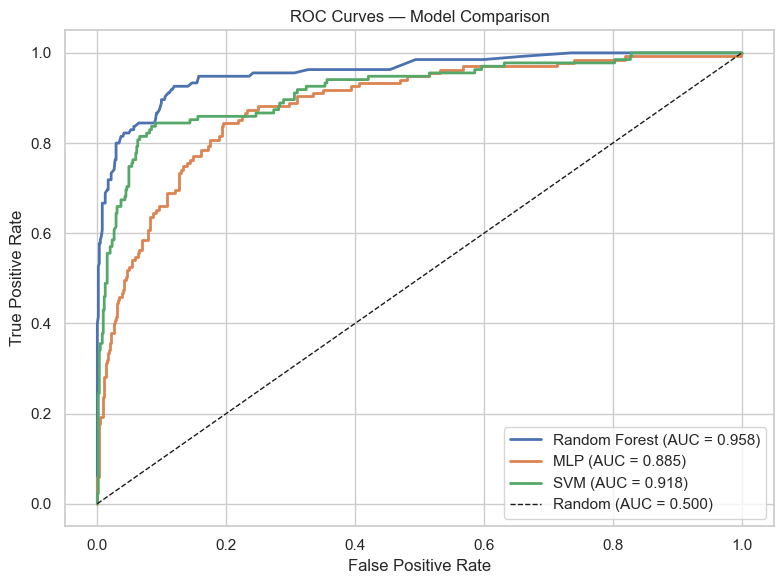

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random (AUC = 0.500)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Model Comparison")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

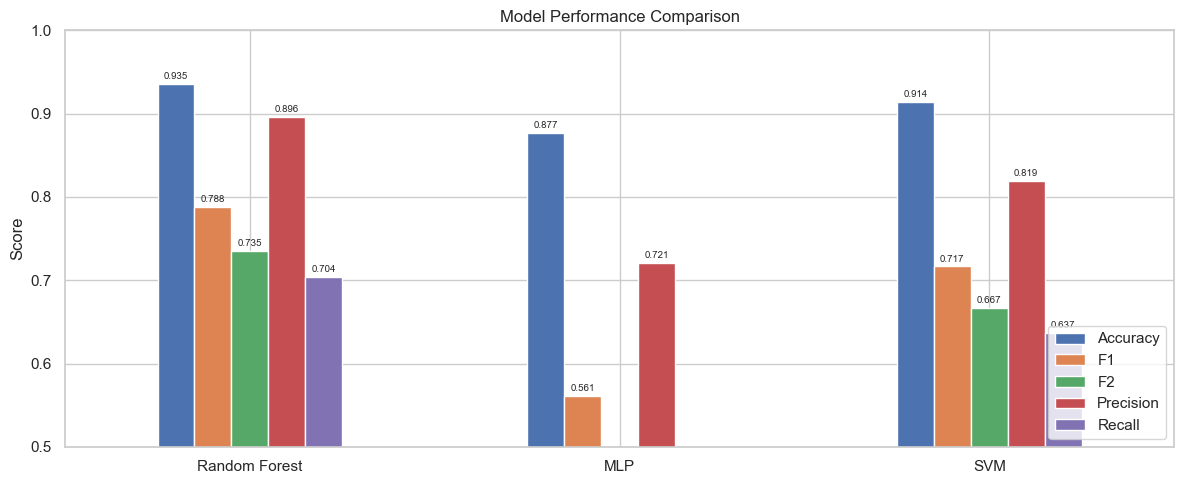

               Accuracy      F1      F2  Precision  Recall
Random Forest    0.9354  0.7884  0.7353     0.8962  0.7037
MLP              0.8771  0.5611  0.4952     0.7209  0.4593
SVM              0.9138  0.7167  0.6667     0.8190  0.6370


In [17]:
metrics_df = pd.DataFrame({
    name: {"Accuracy": r["accuracy"], "F1": r["f1"], "F2": r["f2"], "Precision": r["precision"], "Recall": r["recall"]}
    for name, r in results.items()
}).T

fig, ax = plt.subplots(figsize=(12, 5))
metrics_df.plot(kind="bar", ax=ax, rot=0)
ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison")
ax.set_ylim(0.5, 1.0)
ax.legend(loc="lower right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=7, padding=2)

plt.tight_layout()
plt.show()

print(metrics_df.round(4).to_string())

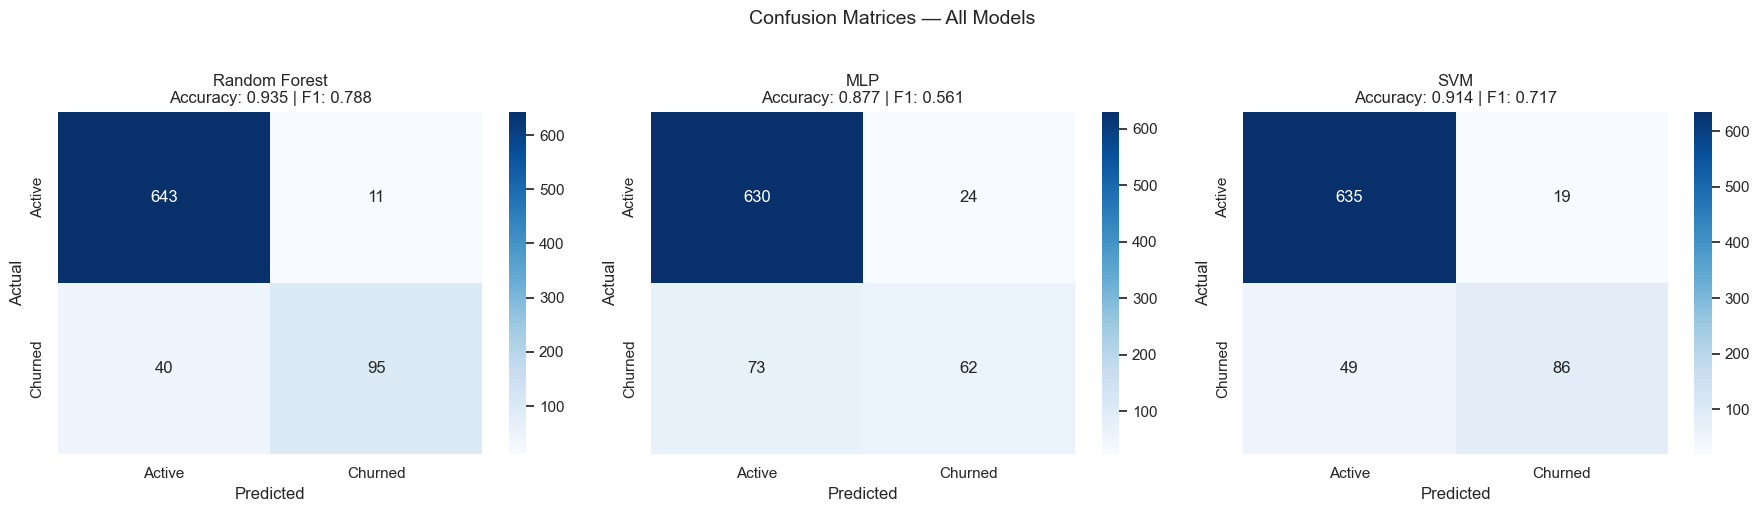

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Active", "Churned"],
                yticklabels=["Active", "Churned"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"{name}\nAccuracy: {res['accuracy']:.3f} | F1: {res['f1']:.3f}")

plt.suptitle("Confusion Matrices — All Models", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5b. SHAP Feature Importance

SHAP (SHapley Additive exPlanations) values show how much each feature pushes a prediction toward or away from churn. We use `TreeExplainer` for Random Forest and `KernelExplainer` for MLP and SVM.

In [19]:
shap_values = {}

models_config = {
    "Random Forest": (best_model, X_test),
    "MLP": (best_mlp, X_test_scaled),
    "SVM": (best_svm, X_test_scaled),
}

for name, (mdl, data) in models_config.items():
    if name == "Random Forest":
        explainer = shap.Explainer(mdl)
        sv = explainer(data)
        shap_values[name] = sv
        print(f"{name}: done")
    else:
        explainer = shap.Explainer(mdl.predict_proba, X_train_scaled)
        sv = explainer(data)
        shap_values[name] = sv
        print(f"{name}: done")

Random Forest: done


PermutationExplainer explainer: 790it [00:51, 14.28it/s]                                                               


MLP: done


PermutationExplainer explainer: 790it [29:55,  2.28s/it]                                                               

SVM: done


In [20]:
for name, sv in shap_values.items():
    print(name,np.abs(sv.values).mean(axis=0))

Random Forest [[0.12080659 0.12080659]
 [0.01684748 0.01684748]
 [0.01389937 0.01389937]
 [0.0160522  0.0160522 ]
 [0.02485465 0.02485465]
 [0.058538   0.058538  ]
 [0.02443696 0.02443696]
 [0.02383173 0.02383173]
 [0.00134132 0.00134132]
 [0.02061495 0.02061495]
 [0.00758297 0.00758297]
 [0.00850937 0.00850937]
 [0.00120912 0.00120912]
 [0.01866875 0.01866875]
 [0.02437921 0.02437921]]
MLP [[0.09181193 0.09181193]
 [0.02235779 0.02235779]
 [0.02629263 0.02629263]
 [0.03022491 0.03022491]
 [0.03524659 0.03524659]
 [0.07670178 0.07670178]
 [0.01732452 0.01732452]
 [0.00792181 0.00792181]
 [0.00195545 0.00195545]
 [0.04260066 0.04260066]
 [0.01501764 0.01501764]
 [0.00428986 0.00428986]
 [0.0020159  0.0020159 ]
 [0.01381783 0.01381783]
 [0.0369499  0.0369499 ]]
SVM [[0.09641251 0.09641251]
 [0.02974684 0.02974684]
 [0.0198291  0.0198291 ]
 [0.01845272 0.01845272]
 [0.03517967 0.03517967]
 [0.05646942 0.05646942]
 [0.02301587 0.02301587]
 [0.02738802 0.02738802]
 [0.00954755 0.00954755]
 

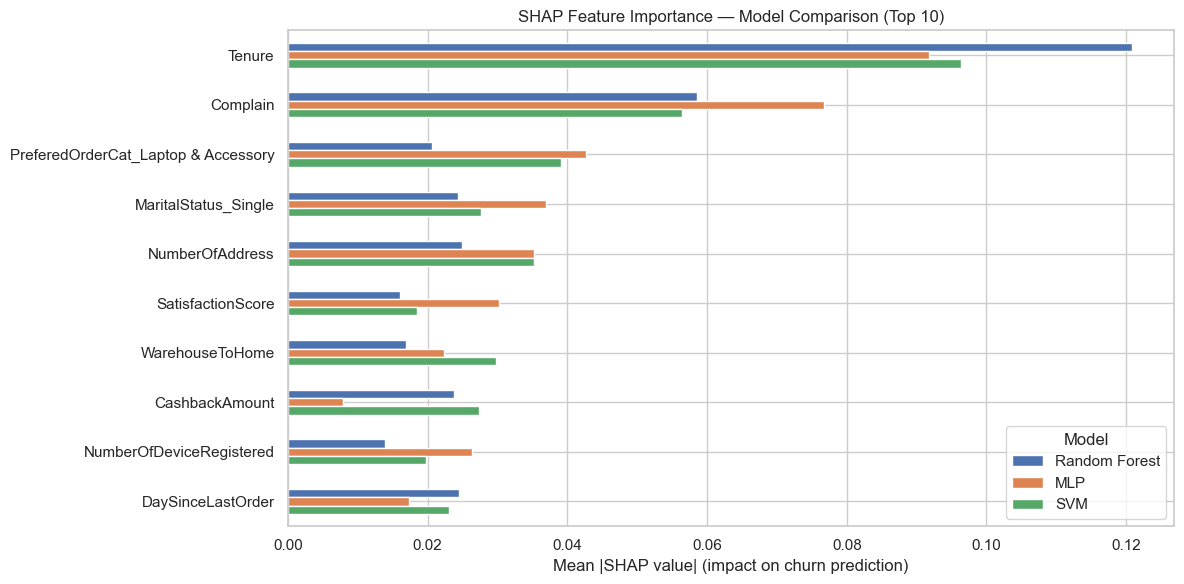

In [21]:
importance_df = pd.DataFrame({
    name: np.abs(sv.values[:, :, 1] if sv.values.ndim == 3 else sv.values).mean(axis=0)
    for name, sv in shap_values.items()
}, index=X_test.columns)

top_features = importance_df.max(axis=1).sort_values(ascending=False).head(10).index
plot_df = importance_df.loc[top_features]

fig, ax = plt.subplots(figsize=(12, 6))
plot_df.plot(kind="barh", ax=ax)
ax.set_xlabel("Mean |SHAP value| (impact on churn prediction)")
ax.set_title("SHAP Feature Importance — Model Comparison (Top 10)")
ax.invert_yaxis()
ax.legend(title="Model")
plt.tight_layout()
plt.show()

## 6. Select & Save Best Model

The model with the highest F2 score on the test set is selected as the winner. F2 weighs recall 4x more than precision — better for churn where missing a churner is costlier than a false alarm.

In [22]:
best_name = max(results, key=lambda k: results[k]["f2"])
best_result = results[best_name]
print(f"Winner: {best_name} (F2 = {best_result['f2']:.4f})")

winner_scaler = scaler if best_result["needs_scaler"] else None

os.makedirs("../models", exist_ok=True)

artifact = {
    "model": best_result["model"],
    "feature_columns": list(X.columns),
    "impute_medians": impute_medians,
    "scaler": winner_scaler,
    "model_name": best_name,
}
joblib.dump(artifact, "../models/churn_model.pkl")

print(f"Artifact saved to models/churn_model.pkl")
print(f"  Model: {best_name}")
print(f"  Scaler included: {winner_scaler is not None}")
print(f"  Feature columns ({len(artifact['feature_columns'])}): {artifact['feature_columns']}")
print(f"  Impute medians: {artifact['impute_medians']}")

Winner: Random Forest (F2 = 0.7353)
Artifact saved to models/churn_model.pkl
  Model: Random Forest
  Scaler included: False
  Feature columns (15): ['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'DaySinceLastOrder', 'CashbackAmount', 'PreferedOrderCat_Grocery', 'PreferedOrderCat_Laptop & Accessory', 'PreferedOrderCat_Mobile', 'PreferedOrderCat_Mobile Phone', 'PreferedOrderCat_Others', 'MaritalStatus_Married', 'MaritalStatus_Single']
  Impute medians: {'Tenure': 9.0, 'WarehouseToHome': 14.0, 'DaySinceLastOrder': 3.0}


SHAP beeswarm plot for the winning model: Random Forest


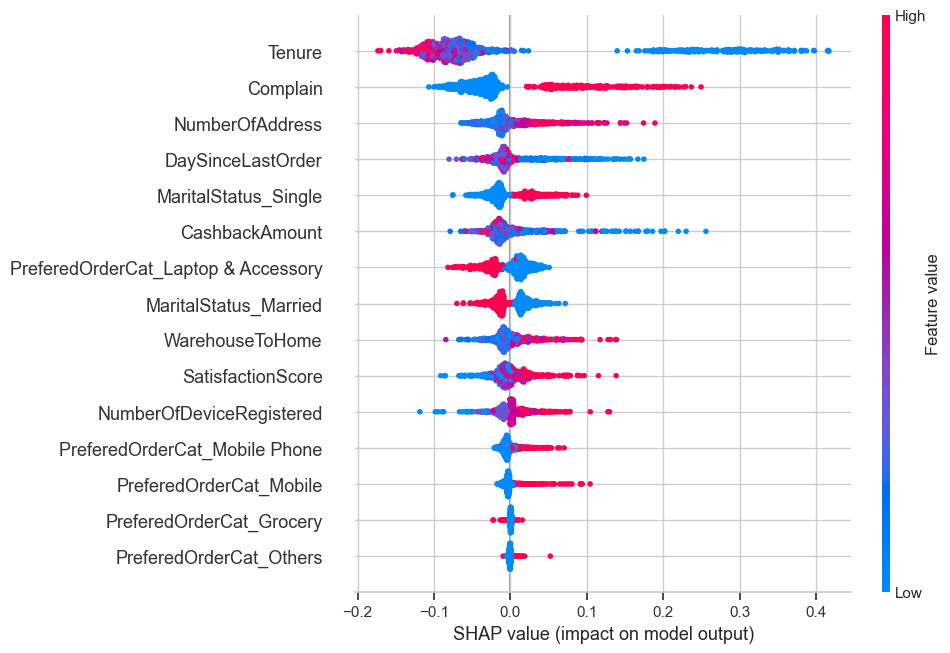

In [23]:
print(f"SHAP beeswarm plot for the winning model: {best_name}")
sv_best = shap_values[best_name]                                                                                             
if sv_best.values.ndim == 3:
    sv_best = sv_best[:, :, 1]  # churn class only  
shap.plots.beeswarm(sv_best, max_display=15)

In [24]:
loaded = joblib.load("../models/churn_model.pkl")
sample = X_test.iloc[:1]
if loaded["scaler"] is not None:
    sample = pd.DataFrame(
        loaded["scaler"].transform(sample),
        columns=sample.columns,
        index=sample.index,
    )
prob = loaded["model"].predict_proba(sample)[0]
print(f"Verification — Active: {prob[0]:.1%}, Churned: {prob[1]:.1%}")
print(f"Model: {loaded['model_name']}")
print("Done!")

Verification — Active: 98.0%, Churned: 2.0%
Model: Random Forest
Done!
